# Tier 1 Pedal Effects — Clean Boost & Tone Filtering

**What you will learn in this notebook:**

1. How to synthesise a realistic guitar chord from sine waves + harmonics
2. What a **Tier 1 (linear, time-invariant)** pedal effect looks like mathematically and visually
3. Why you need a **broadband identification signal** (not just the chord) to fit a model
4. How **FIR** and **IIR** models capture linear effects — and why they score near-zero ESR
5. What the metrics (ESR, STFT loss, HP similarity) actually tell you

---

## Background: Tier 1 = linear, time-invariant (LTI)

A **Tier 1** pedal effect satisfies two conditions:

| Property | Meaning | Fails when... |
|----------|---------|---------------|
| **Linear** | doubling the input doubles the output | the circuit clips or saturates |
| **Time-invariant** | the response doesn't change over time | the effect has memory that depends on signal history (e.g. envelope followers, compressors) |

Real-world examples: a clean boost pedal, a passive tone control, a buffer, a passive EQ.

**For a perfect LTI system:** the FIR or IIR model should capture it **exactly**, giving ESR → 0.

> If ESR is not near zero after fitting an FIR/IIR model, either the system is **not linear** (→ Tier 2/3) or the identification signal didn't cover all frequencies.

## 0. Imports and setup

In [ ]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.signal import butter, sosfilt

from pedal_model.models.classical.fir import FIRModel
from pedal_model.models.classical.iir import IIRModel
from pedal_model.metrics.suite import compute_all_metrics

# All plotting and signal utilities from the library
from pedal_model.utils import (
    # Synthesis
    guitar_note, g_major_chord, white_noise_id,
    # Analysis
    safe_trim, compute_esr_skip, harmonic_frequencies, peak_db, rms_db,
    # Spectral
    db_spectrum, freq_response_db, filter_impulse_response,
    # Axis helpers
    mark_harmonics, mark_vlines,
    # Plots
    plot_waveform, plot_spectrum, plot_impulse_response, plot_freq_response,
    compare_waveforms, compare_spectra, signal_dashboard,
    error_analysis_panel, ir_overlay, freq_response_overlay, model_fit_panel,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
SR = 48_000
SKIP = 512   # warmup samples excluded from ESR / metric calculations
print(f'Sample rate: {SR} Hz')

---
## 1. Build the G major chord

### 1a. Why harmonics matter

A real guitar string doesn't vibrate at a single frequency. It vibrates at its fundamental $f_0$
**and all its integer multiples** (harmonics): $f_0, 2f_0, 3f_0, \ldots$

The harmonic amplitudes fall off roughly as $1/k$ for the $k$-th harmonic.
This is what gives a guitar its characteristic timbre (as opposed to a pure sine wave).

```
G major chord = D3 (147 Hz) + G3 (196 Hz) + B3 (247 Hz)
```

Including harmonics is important here: the **tone filter** effect only becomes visually and
aurally interesting when there is high-frequency content to cut.

In [ ]:
# guitar_note and g_major_chord are now in pedal_model.utils.synthesis
# (imported above) — no need to define them inline.

DURATION = 2.0   # seconds
AMP = 0.2        # per-note amplitude: combined chord peaks at ~-6 dBFS

d3 = guitar_note(147, sr=SR, duration=DURATION, amp=AMP)
g3 = guitar_note(196, sr=SR, duration=DURATION, amp=AMP)
b3 = guitar_note(247, sr=SR, duration=DURATION, amp=AMP)

chord = (d3 + g3 + b3).astype(np.float32)

print(f'Chord length  : {len(chord):,} samples  ({DURATION:.1f} s)')
print(f'Peak amplitude: {np.max(np.abs(chord)):.4f}  ({peak_db(chord):.1f} dBFS)')
print(f'RMS amplitude : {np.sqrt(np.mean(chord**2)):.4f}  ({rms_db(chord):.1f} dBFS)')

### 1b. Visualise each individual note

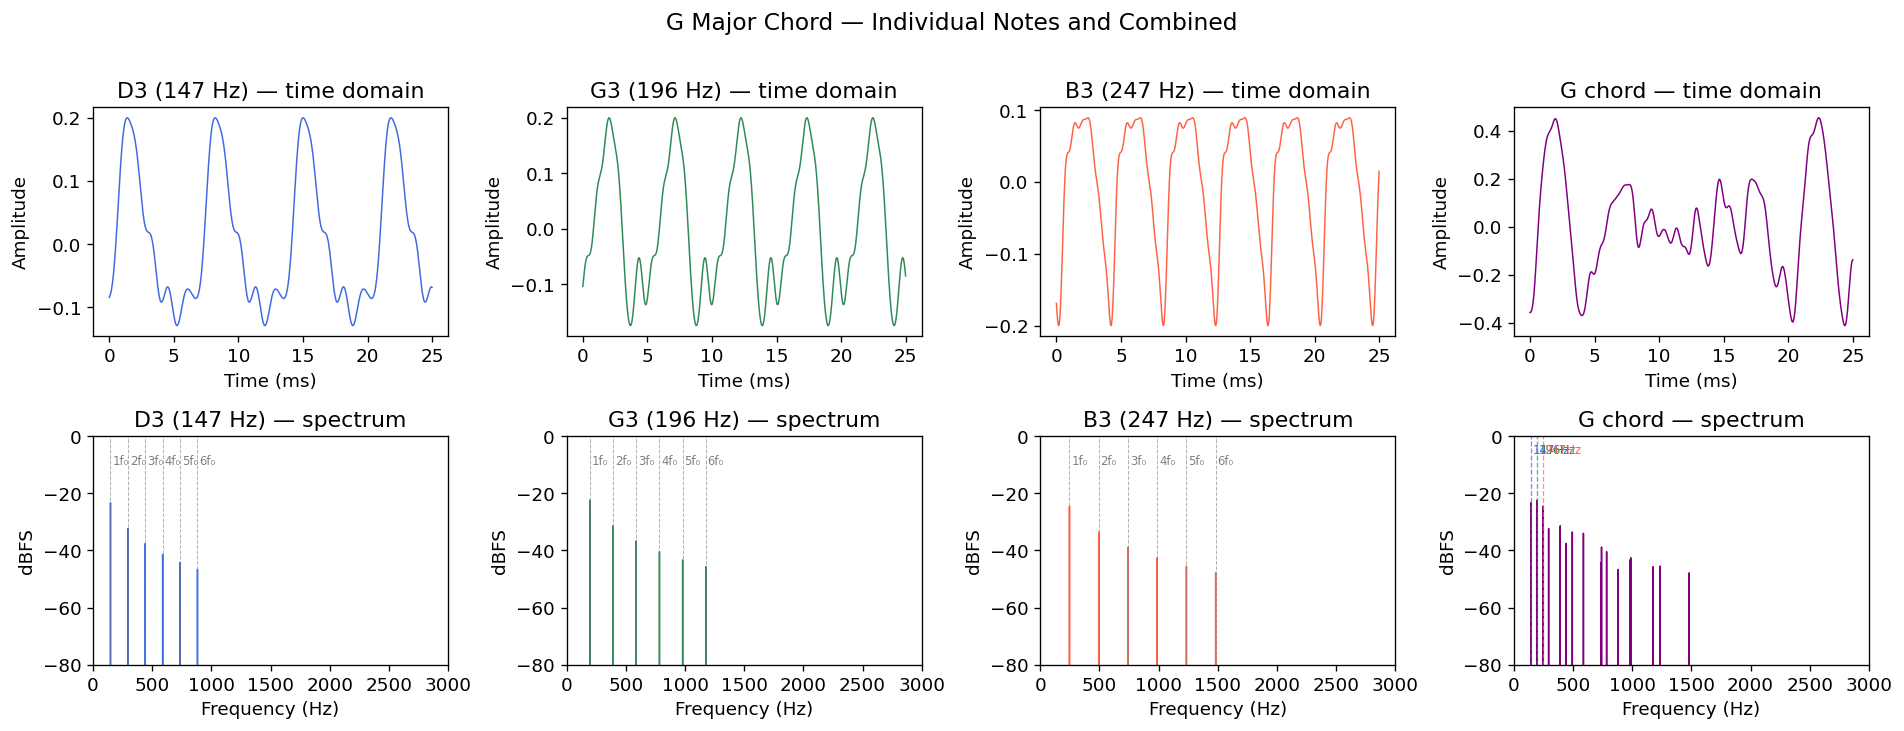


Observations:
  • Each note shows its fundamental + harmonics as vertical spikes in the spectrum
  • The chord spectrum is a superposition of all three note spectra
  • The time-domain chord waveform is more complex because the notess frequencies are incommensurable


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
notes = {'D3 (147 Hz)': (d3, 'royalblue'), 'G3 (196 Hz)': (g3, 'seagreen'), 'B3 (247 Hz)': (b3, 'tomato')}
ms = 25

for col, (name, (sig, color)) in enumerate(notes.items()):
    # Time domain
    n_show = int(SR * ms / 1000)
    t_ms = np.arange(n_show) / SR * 1000
    axes[0, col].plot(t_ms, sig[:n_show], color=color, lw=0.9)
    axes[0, col].set_title(f'{name} — time domain')
    axes[0, col].set_xlabel('Time (ms)')
    axes[0, col].set_ylabel('Amplitude')

    # Spectrum
    freqs, mag_db = db_spectrum(sig, SR)
    axes[1, col].plot(freqs, mag_db, color=color, lw=0.9)
    axes[1, col].set_xlim(0, 3000)
    axes[1, col].set_ylim(-80, 0)
    axes[1, col].set_title(f'{name} — spectrum')
    axes[1, col].set_xlabel('Frequency (Hz)')
    axes[1, col].set_ylabel('dBFS')
    # Mark harmonics
    f0 = [147, 196, 247][col]
    for k in range(1, 7):
        if k * f0 < 3000:
            axes[1, col].axvline(k * f0, color='gray', lw=0.6, ls='--', alpha=0.6)
            axes[1, col].text(k * f0 + 15, -10, f'{k}f₀', fontsize=7, color='gray')

# Chord (4th column)
n_show = int(SR * ms / 1000)
t_ms = np.arange(n_show) / SR * 1000
axes[0, 3].plot(t_ms, chord[:n_show], color='purple', lw=0.9)
axes[0, 3].set_title('G chord — time domain')
axes[0, 3].set_xlabel('Time (ms)')
axes[0, 3].set_ylabel('Amplitude')

freqs, mag_db = db_spectrum(chord, SR)
axes[1, 3].plot(freqs, mag_db, color='purple', lw=0.9)
axes[1, 3].set_xlim(0, 3000)
axes[1, 3].set_ylim(-80, 0)
axes[1, 3].set_title('G chord — spectrum')
axes[1, 3].set_xlabel('Frequency (Hz)')
axes[1, 3].set_ylabel('dBFS')
for f0_note, color in [(147, 'royalblue'), (196, 'seagreen'), (247, 'tomato')]:
    axes[1, 3].axvline(f0_note, color=color, lw=0.8, ls='--', alpha=0.7)
    axes[1, 3].text(f0_note + 10, -6, f'{f0_note}Hz', fontsize=7, color=color)

fig.suptitle('G Major Chord — Individual Notes and Combined', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nObservations:')
print('  • Each note shows its fundamental + harmonics as vertical spikes in the spectrum')
print('  • The chord spectrum is a superposition of all three note spectra')
print('  • The time-domain chord waveform is more complex because the notess frequencies are incommensurable')

### 1c. Why a tonal signal is bad for system identification

The chord signal has energy **only at its harmonic frequencies** — it is zero everywhere else.

System identification works by dividing $H(\omega) = \text{WET}(\omega) / \text{DRY}(\omega)$ in the frequency domain.
If DRY is zero at most frequencies (as it is for a chord), the division produces garbage at those frequencies,
and the recovered impulse response is corrupted by noise.

**Solution:** use a **broadband identification signal** (white noise or log sweep) to fit the model, then apply the model to the chord. This is exactly the workflow described in the capture plan — the sweep is for identification, the guitar is for listening.

We will demonstrate the failure case first, then fix it.

---
## 2. Effect A — Clean Boost

### 2a. The math

A clean boost multiplies every sample by a constant gain $G$:

$$y[n] = G \cdot x[n]$$

In the frequency domain: $Y(\omega) = G \cdot X(\omega)$ — the spectrum scales uniformly, no frequency shaping.

In the Z-domain: $H(z) = G$ — a single-tap FIR filter, the simplest possible LTI system.

**The ideal FIR kernel should be:** $h[0] = G,\ h[k] = 0 \text{ for } k > 0$

We use $G = 4.0$ (+12 dB gain).

In [4]:
BOOST_GAIN = 4.0   # +12 dB
BOOST_DB   = 20 * np.log10(BOOST_GAIN)

chord_boost_wet = (chord * BOOST_GAIN).astype(np.float32)

print(f'Gain: {BOOST_GAIN:.1f}×  ({BOOST_DB:.1f} dB)')
print(f'Dry peak : {np.max(np.abs(chord)):.4f}  ({20*np.log10(np.max(np.abs(chord))):.1f} dBFS)')
print(f'Wet peak : {np.max(np.abs(chord_boost_wet)):.4f}  ({20*np.log10(np.max(np.abs(chord_boost_wet))):.1f} dBFS)')

Gain: 4.0×  (12.0 dB)
Dry peak : 0.4995  (-6.0 dBFS)
Wet peak : 1.9978  (6.0 dBFS)


### 2b. Visualise boost — time domain and FFT

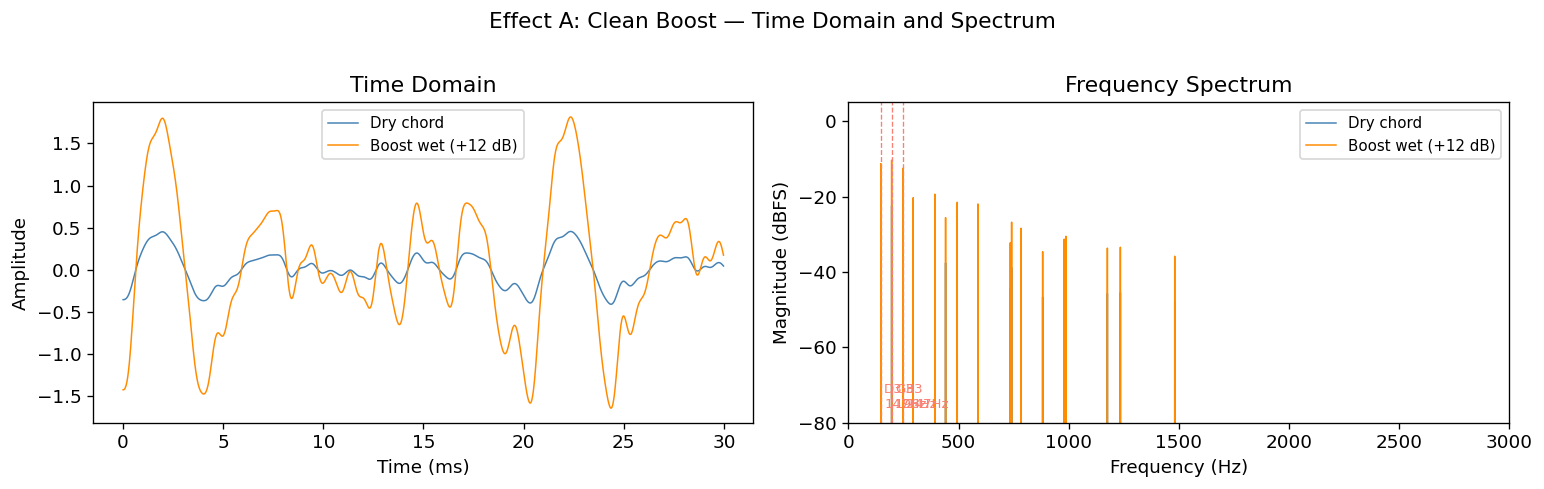

Observations:
  • The time-domain waveform is identical in shape, just scaled up
  • The spectrum is identical in shape, shifted up uniformly by 12.041199826559248 dB
  • No new frequencies appear — this is a LINEAR effect


In [5]:
fig = signal_dashboard(
    signals={
        'Dry chord': (chord, 'steelblue'),
        f'Boost wet (+{BOOST_DB:.0f} dB)': (chord_boost_wet, 'darkorange'),
    },
    sr=SR,
    title='Effect A: Clean Boost — Time Domain and Spectrum',
    ms=30,
    max_freq=3000,
    vlines={'D3\n147Hz': 147, 'G3\n196Hz': 196, 'B3\n247Hz': 247},
)
plt.show()

print('Observations:')
print('  • The time-domain waveform is identical in shape, just scaled up')
print('  • The spectrum is identical in shape, shifted up uniformly by', BOOST_DB, 'dB')
print('  • No new frequencies appear — this is a LINEAR effect')

### 2c. The identification signal problem — why the chord fails

Let's try to fit the FIR model directly to the chord and see what happens.

FIR fit on chord signal → ESR = 0.976073
Expected ESR             → ≈ 0.000001  (for a pure gain boost)

The ESR is BAD — identification failed.


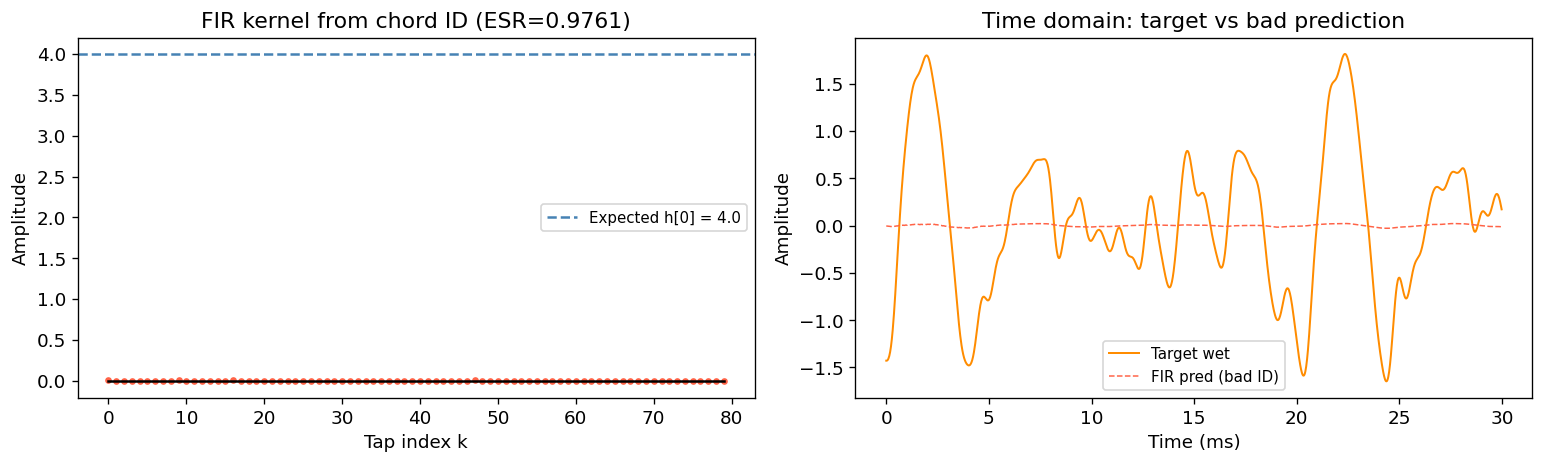


Why did this fail?
  The chord has energy ONLY at 147, 196, 247 Hz and their harmonics.
  H(ω) = WET(ω) / DRY(ω) is undefined (0/0) at all other frequencies.
  The corrupted H(ω) produces a noisy impulse response when inverted.


In [6]:
# Attempt 1: identify from the chord itself (will fail)
fir_chord_id = FIRModel(n_taps=512)
fir_chord_id.fit(chord, chord_boost_wet, SR)
chord_boost_pred_bad = fir_chord_id.predict(chord)

SKIP = 512  # skip transient warmup samples
n = min(len(chord_boost_wet), len(chord_boost_pred_bad))
esr_bad = np.sum((chord_boost_wet[SKIP:n] - chord_boost_pred_bad[SKIP:n])**2) / \
          (np.sum(chord_boost_wet[SKIP:n]**2) + 1e-8)

print(f'FIR fit on chord signal → ESR = {esr_bad:.6f}')
print(f'Expected ESR             → ≈ 0.000001  (for a pure gain boost)')
print(f'\nThe ESR is {"good" if esr_bad < 0.01 else "BAD — identification failed"}.')

# Show the kernel — should be [4, 0, 0, ...] but will be noisy
kernel_bad = fir_chord_id._kernel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_impulse_response(kernel_bad, label='FIR kernel (identified from chord)', color='tomato', ax=ax1, n_show=80)
ax1.axhline(BOOST_GAIN, color='steelblue', ls='--', lw=1.5, label=f'Expected h[0] = {BOOST_GAIN}')
ax1.legend(fontsize=9)
ax1.set_title(f'FIR kernel from chord ID (ESR={esr_bad:.4f})')

n_show = int(SR * 0.03)
t_ms = np.arange(n_show) / SR * 1000
ax2.plot(t_ms, chord_boost_wet[:n_show], color='darkorange', lw=1.2, label='Target wet')
ax2.plot(t_ms, chord_boost_pred_bad[:n_show], color='tomato', ls='--', lw=0.9, label='FIR pred (bad ID)')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Amplitude')
ax2.set_title('Time domain: target vs bad prediction')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nWhy did this fail?')
print('  The chord has energy ONLY at 147, 196, 247 Hz and their harmonics.')
print('  H(ω) = WET(ω) / DRY(ω) is undefined (0/0) at all other frequencies.')
print('  The corrupted H(ω) produces a noisy impulse response when inverted.')

### 2d. Fix: use a broadband identification signal

White noise has (approximately) equal energy at every frequency, so $\text{DRY}(\omega) \neq 0$ everywhere.
The division $H(\omega) = \text{WET}(\omega) / \text{DRY}(\omega)$ is stable and well-conditioned.

**Workflow:**
1. Generate white noise → call it the "identification signal"
2. Apply the effect (boost/filter) → get the "identification wet"
3. Fit FIR/IIR to the (id_dry, id_wet) pair
4. Apply the fitted model to the chord → evaluate quality

In [ ]:
# white_noise_id is in pedal_model.utils.synthesis (imported above)
id_dry = white_noise_id(SR, duration=4.0, amplitude=0.3, seed=42)

# Apply boost to the identification signal
id_boost_wet = (id_dry * BOOST_GAIN).astype(np.float32)

print(f'Identification signal: {len(id_dry):,} samples  ({len(id_dry)/SR:.0f}s)')
print(f'ID dry  peak: {peak_db(id_dry):.1f} dBFS')
print(f'ID wet  peak: {peak_db(id_boost_wet):.1f} dBFS')

fig = signal_dashboard(
    signals={
        'ID signal (white noise)': (id_dry, 'gray'),
        f'ID boosted (+{BOOST_DB:.0f} dB wet)': (id_boost_wet, 'darkorange'),
    },
    sr=SR,
    title='Identification Signal — White Noise (broadband, covers all frequencies)',
    ms=20,
    max_freq=5000,
)
plt.show()
print('\nNote: both spectra are FLAT (white noise has equal energy at all frequencies).')
print('The boost just shifts the whole spectrum up by', BOOST_DB, 'dB.')

### 2e. Fit FIR model using the broadband identification signal

=== FIR Boost kernel analysis ===
h[0]   = 4.000000   (expected ≈ 4.0)
h[1]   = 7.91e-10   (expected ≈ 0)
h[2]   = -1.76e-09
max|h[1:]| = 3.67e-09   (noise floor)
energy in h[0]   : 16.000000
energy in h[1:]  : 4.13e-16


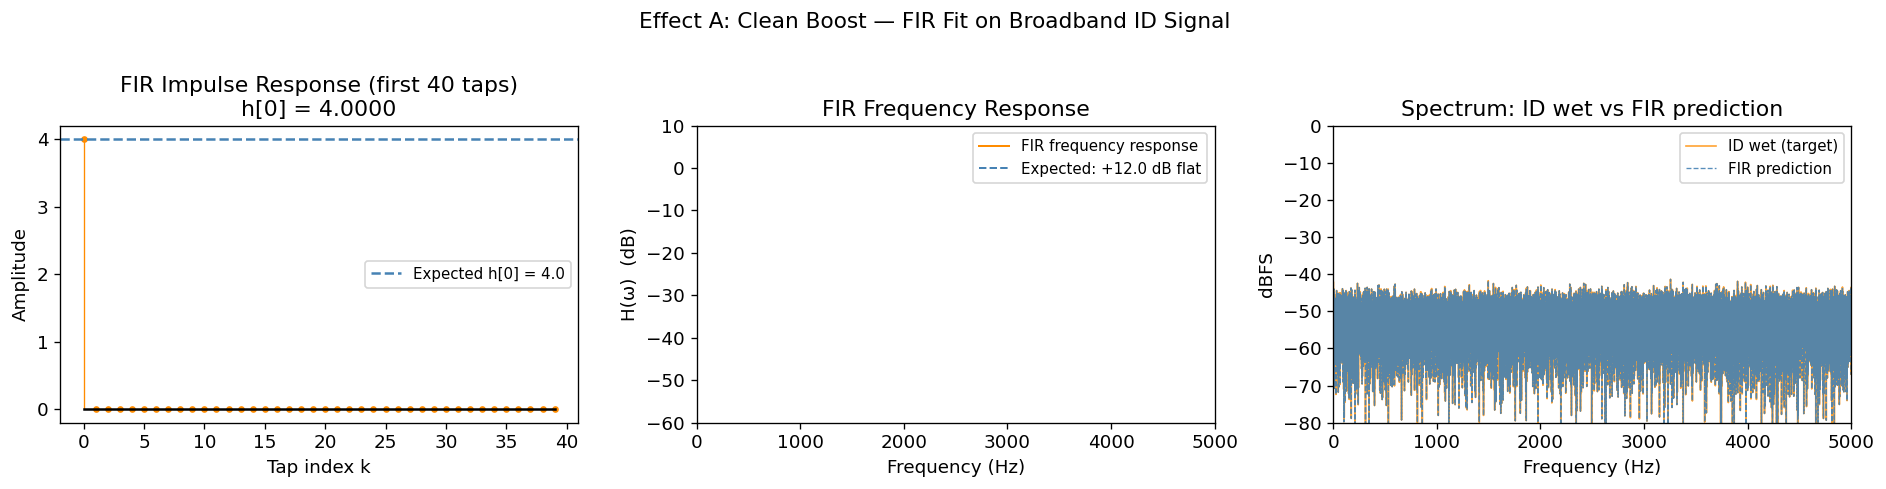

In [8]:
fir_boost = FIRModel(n_taps=512)
fir_boost.fit(id_dry, id_boost_wet, SR)

kernel_boost = fir_boost._kernel

print('=== FIR Boost kernel analysis ===')
print(f'h[0]   = {kernel_boost[0]:.6f}   (expected ≈ {BOOST_GAIN})')
print(f'h[1]   = {kernel_boost[1]:.2e}   (expected ≈ 0)')
print(f'h[2]   = {kernel_boost[2]:.2e}')
print(f'max|h[1:]| = {np.max(np.abs(kernel_boost[1:])):.2e}   (noise floor)')
print(f'energy in h[0]   : {kernel_boost[0]**2:.6f}')
print(f'energy in h[1:]  : {np.sum(kernel_boost[1:]**2):.2e}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Kernel taps
plot_impulse_response(kernel_boost, label=f'FIR kernel — boost', color='darkorange', ax=axes[0], n_show=40)
axes[0].axhline(BOOST_GAIN, color='steelblue', ls='--', lw=1.5, label=f'Expected h[0] = {BOOST_GAIN}')
axes[0].legend(fontsize=9)
axes[0].set_title(f'FIR Impulse Response (first 40 taps)\nh[0] = {kernel_boost[0]:.4f}')

# 2. Kernel frequency response (dB) — should be flat at +12dB
plot_freq_response(kernel_boost, SR, label='FIR frequency response', color='darkorange', ax=axes[1], max_freq=5000)
axes[1].axhline(BOOST_DB, color='steelblue', ls='--', lw=1.2, label=f'Expected: +{BOOST_DB:.1f} dB flat')
axes[1].set_title('FIR Frequency Response')
axes[1].legend(fontsize=9)

# 3. Prediction on ID signal spectrum
id_boost_pred = fir_boost.predict(id_dry)
freqs, m_wet = db_spectrum(id_boost_wet, SR)
freqs, m_pred = db_spectrum(id_boost_pred, SR)
axes[2].plot(freqs, m_wet,  'darkorange', lw=1.0, label='ID wet (target)', alpha=0.8)
axes[2].plot(freqs, m_pred, 'steelblue',  lw=0.8, ls='--', label='FIR prediction', alpha=0.9)
axes[2].set_xlim(0, 5000)
axes[2].set_ylim(-80, 0)
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('dBFS')
axes[2].set_title('Spectrum: ID wet vs FIR prediction')
axes[2].legend(fontsize=9)

plt.suptitle('Effect A: Clean Boost — FIR Fit on Broadband ID Signal', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**
- `h[0] ≈ 4.0` and all other taps are near zero — exactly the expected delta-function kernel
- The frequency response is **flat at +12 dB** across the whole spectrum
- The FIR perfectly captured the boost

### 2f. Apply the fitted boost model to the G chord

In [ ]:
chord_boost_pred = fir_boost.predict(chord)

# error_analysis_panel handles trimming, error computation, and all four subplots
fig = error_analysis_panel(
    target=chord_boost_wet,
    predicted=chord_boost_pred,
    sr=SR,
    skip=SKIP,
    ms=30,
    max_freq=3000,
    target_color='darkorange',
    pred_color='navy',
    title=f'Effect A: Clean Boost — FIR Applied to G Chord',
)
plt.show()

### 2g. Metrics for the boost

In [ ]:
n = min(len(chord_boost_wet), len(chord_boost_pred))
metrics_boost = compute_all_metrics(
    target=chord_boost_wet[SKIP:n],
    predicted=chord_boost_pred[SKIP:n],
    input_signal=chord[SKIP:n],
    sr=SR,
    harmonic_f0=196.0,
)

print('╔══════════════════════════════════════════════════════════════╗')
print('║           BOOST — FIR Model Metrics                         ║')
print('╠════════════════╦═══════════╦══════════════════════════════════╣')
print('║ Metric         ║   Value   ║  Interpretation                  ║')
print('╠════════════════╬═══════════╬══════════════════════════════════╣')

interpretations = {
    'ESR':      ('Error-to-Signal Ratio. 0=perfect, 1=silence output. <0.01=excellent', 0.01),
    'MSE':      ('Mean Squared Error. Raw squared amplitude error.', None),
    'DC_err':   ('DC offset error. Should be near 0.', 0.001),
    'RMS_err':  ('Root-mean-square error in amplitude.', None),
    'STFT':     ('Multi-scale spectral loss. 0=identical spectra. <0.1=excellent.', 0.1),
    'FR_err_dB':('Frequency response error in dB. <1dB=excellent.', 1.0),
    'THD_target':('THD% of the TARGET signal at 196Hz. How much distortion exists?', None),
    'THD_pred': ('THD% of the PREDICTION. Should match target.', None),
    'THD_err':  ('|THD_target - THD_pred|. 0=model captures distortion correctly.', 1.0),
    'HP_sim':   ('Harmonic Profile Similarity. 1.0=identical harmonic structure.', None),
    'MCD':      ('Mel Cepstral Distortion in dB. <2dB=good tonal similarity.', 2.0),
}
for k, v in metrics_boost.items():
    thresh = interpretations[k][1]
    flag = '' if thresh is None else ('✓' if (v < thresh if k != 'HP_sim' else v > 0.99) else '✗')
    print(f'║ {k:<14}  ║ {v:9.6f} ║  {flag} {interpretations[k][0][:42]:<42} ║')
print('╚════════════════╩═══════════╩══════════════════════════════════╝')

**What the metrics tell us for a clean boost:**

- **ESR ≈ 0**: The FIR perfectly reconstructs the boosted signal — as expected for a single-tap kernel
- **THD_err ≈ 0**: No new harmonics were added (linear effect)
- **HP_sim ≈ 1**: The harmonic structure is unchanged — boost doesn't alter the tone, just the level

> **Learning point:** If a real-world pedal labelled "clean boost" gives ESR > 0.01, it means the pedal is
> adding some nonlinearity or frequency shaping — it's not as clean as advertised.

---

## 3. Effect B — Tone Filter (Low-Pass, "Warm" Rolloff)

### 3a. The math

A **4th-order Butterworth low-pass filter** with cutoff at $f_c = 600$ Hz.

The Butterworth filter is maximally flat in the passband — no ripple.
Its magnitude response is:

$$|H(j\omega)|^2 = \frac{1}{1 + (\omega/\omega_c)^{2N}}$$

With $N=4$: at $f_c = 600$ Hz, the gain is $-3$ dB. Above $f_c$, the gain rolls off at $-80$ dB/decade.

**Effect on our chord:**
- D3 fundamental (147 Hz): passes through at ~0 dB ✓
- G3 fundamental (196 Hz): passes through at ~0 dB ✓  
- B3 fundamental (247 Hz): passes through at ~0 dB ✓
- 3rd harmonics (440–740 Hz): partially attenuated ⚠
- Higher harmonics (>1 kHz): heavily attenuated ✗

The result sounds **darker and warmer** — the overtones are removed, leaving only the fundamental tones.

In [ ]:
CUTOFF_HZ = 600.0
FILTER_ORDER = 4

sos_lp = butter(FILTER_ORDER, CUTOFF_HZ, btype='low', fs=SR, output='sos')

# Apply filter to both chord and identification signal
chord_filter_wet = sosfilt(sos_lp, chord).astype(np.float32)
id_filter_wet    = sosfilt(sos_lp, id_dry).astype(np.float32)

# Get the true impulse response by filtering a Kronecker delta
# (do NOT pass zi= here — let sosfilt handle initial conditions automatically)
from pedal_model.utils.plotting import filter_impulse_response
impulse_out = filter_impulse_response(sos_lp, n=4096)
true_freqs, true_H_db = db_spectrum(impulse_out, SR, n_fft=4096)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. True filter frequency response
axes[0].plot(true_freqs, true_H_db, 'mediumseagreen', lw=1.5, label='Butterworth LP')
axes[0].axvline(CUTOFF_HZ, color='salmon', ls='--', lw=1.2, label=f'Cutoff: {CUTOFF_HZ:.0f} Hz')
axes[0].axhline(-3, color='gray', ls=':', lw=0.8, label='-3 dB')
axes[0].set_xlim(0, 5000)
axes[0].set_ylim(-80, 5)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('H(ω) (dB)')
axes[0].set_title(f'True Butterworth LP Response\n(order={FILTER_ORDER}, fc={CUTOFF_HZ:.0f}Hz)')
axes[0].legend(fontsize=9)

# 2. True impulse response
plot_impulse_response(impulse_out, label='True LP impulse response', color='mediumseagreen', ax=axes[1], n_show=100)
axes[1].set_title('Impulse Response of the True LP Filter')

# 3. Chord spectrum: dry vs filtered
for sig, label, color in [
    (chord, 'Dry chord', 'steelblue'),
    (chord_filter_wet, f'LP filtered (fc={CUTOFF_HZ:.0f}Hz)', 'mediumseagreen'),
]:
    freqs_s, m = db_spectrum(sig, SR)
    axes[2].plot(freqs_s, m, label=label, lw=0.9)
axes[2].axvline(CUTOFF_HZ, color='salmon', ls='--', lw=1.0, label=f'Cutoff {CUTOFF_HZ:.0f}Hz')
for f0_note in [147, 196, 247]:
    axes[2].axvline(f0_note, color='gray', lw=0.6, ls=':', alpha=0.5)
axes[2].set_xlim(0, 3000)
axes[2].set_ylim(-80, 0)
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('dBFS')
axes[2].set_title('Chord Spectrum: Before and After Filtering')
axes[2].legend(fontsize=9)

plt.suptitle('Effect B: Low-Pass Tone Filter — Theory', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Observations:')
print('  • The three fundamentals (147, 196, 247Hz) pass through unchanged')
print('  • Harmonics above 600Hz are progressively attenuated')
print(f'  • The -80dB/decade rolloff of a 4th-order Butterworth means')
print(f'    at 6000Hz (10x cutoff), attenuation is about -80dB')

### 3b. Visualise the filter effect on the chord — time and FFT

In [ ]:
fig = signal_dashboard(
    signals={
        'Dry chord': (chord, 'steelblue'),
        f'LP filtered (fc={CUTOFF_HZ:.0f}Hz wet)': (chord_filter_wet, 'mediumseagreen'),
    },
    sr=SR,
    title='Effect B: Low-Pass Tone Filter Applied to Chord',
    ms=30,
    max_freq=3000,
    vlines={
        'D3\n147Hz': 147, 'G3\n196Hz': 196, 'B3\n247Hz': 247,
        f'fc\n{CUTOFF_HZ:.0f}Hz': CUTOFF_HZ,
    },
)
plt.show()

print('Observations:')
print('  • Time domain: the waveform is SMOOTHER — the high-frequency "fuzz" on the peaks is gone')
print('  • Spectrum: content above the cutoff is strongly attenuated')
print('  • The waveform now looks more like a pure sine wave — the harmonics are gone')

### 3c. Visualise the identification signal through the filter

In [ ]:
fig = signal_dashboard(
    signals={
        'ID dry (white noise)': (id_dry, 'gray'),
        f'ID LP filtered (fc={CUTOFF_HZ:.0f}Hz)': (id_filter_wet, 'mediumseagreen'),
    },
    sr=SR,
    title='Identification Signal Through LP Filter (broadband — all frequencies covered)',
    ms=20,
    max_freq=5000,
    vlines={f'fc {CUTOFF_HZ:.0f}Hz': CUTOFF_HZ},
)
plt.show()

print('This is the signal pair we will use to fit FIR and IIR models.')
print('The flat input (white noise) makes system identification well-conditioned.')

### 3d. Fit FIR model to the filter

In [ ]:
fir_filter = FIRModel(n_taps=512)
fir_filter.fit(id_dry, id_filter_wet, SR)

kernel_filter = fir_filter._kernel

print('=== FIR Filter kernel analysis ===')
print(f'h[0]  = {kernel_filter[0]:.6f}')
print(f'h[37] = {kernel_filter[37]:.6f}  (LP IR peak is around tap 37)')
print(f'Max |h|  at tap {np.argmax(np.abs(kernel_filter))}')
print(f'Energy in first 100 taps: {np.sum(kernel_filter[:100]**2):.4f}')
print(f'Energy in taps 100-512  : {np.sum(kernel_filter[100:]**2):.6f}')

# Compare FIR kernel to true IR
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. True vs FIR impulse response
n_show = 100
axes[0].stem(np.arange(n_show), impulse_out[:n_show],
             markerfmt='go', linefmt='g-', basefmt='k-', label='True LP IR')
axes[0].stem(np.arange(n_show), kernel_filter[:n_show],
             markerfmt='bs', linefmt='b--', basefmt='k-', label='FIR fitted')
axes[0].set_xlabel('Tap index k')
axes[0].set_ylabel('h[k]')
axes[0].set_title('True IR vs FIR Kernel (first 100 taps)')
axes[0].legend(fontsize=9)

# 2. Frequency response comparison
plot_freq_response(impulse_out, SR, label='True LP', color='mediumseagreen', ax=axes[1], max_freq=5000)
plot_freq_response(kernel_filter, SR, label='FIR fitted', color='steelblue', ax=axes[1], max_freq=5000, lw=0.9)
axes[1].axvline(CUTOFF_HZ, color='salmon', ls='--', lw=1.0, label=f'fc={CUTOFF_HZ:.0f}Hz')
axes[1].set_title('Frequency Response: True vs FIR')
axes[1].legend(fontsize=9)

# 3. Spectrum: id_filter_wet vs FIR prediction on id signal
id_filter_pred_fir = fir_filter.predict(id_dry)
freqs, m_wet  = db_spectrum(id_filter_wet, SR)
freqs, m_pred = db_spectrum(id_filter_pred_fir, SR)
axes[2].plot(freqs, m_wet,  'mediumseagreen', lw=1.0, label='ID wet target', alpha=0.8)
axes[2].plot(freqs, m_pred, 'steelblue',      lw=0.8, ls='--', label='FIR prediction', alpha=0.9)
axes[2].axvline(CUTOFF_HZ, color='salmon', ls='--', lw=0.8)
axes[2].set_xlim(0, 5000)
axes[2].set_ylim(-80, 0)
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('dBFS')
axes[2].set_title('ID Signal: Wet Spectrum vs FIR Prediction')
axes[2].legend(fontsize=9)

plt.suptitle('Effect B: Low-Pass Filter — FIR Kernel Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nKey observations:')
print('  • The FIR kernel now has MULTIPLE non-zero taps (unlike the boost, which had only h[0])')
print('  • The FIR matches the true LP IR very closely')
print('  • The frequency response matches the true filter rolloff')

### 3e. Fit IIR model to the filter

The original filter **is** an IIR circuit (it has feedback — the $a_k$ coefficients are non-zero).
An IIR model should capture it with far fewer parameters than an FIR:

- FIR with 512 taps: **512 parameters**
- IIR of order 8: **17 parameters** (8 $b$ + 9 $a$ coefficients)

**Trade-off:** IIR is more compact and faster at runtime, but can have stability issues if the poles
land outside the unit circle. We use second-order sections (SOS) to keep it stable.

In [ ]:
iir_filter = IIRModel(order=8, n_freq_points=512)
iir_filter.fit(id_dry, id_filter_wet, SR)

id_filter_pred_iir = iir_filter.predict(id_dry)

n = min(len(id_filter_wet), len(id_filter_pred_fir), len(id_filter_pred_iir))

# compute_esr_skip is in pedal_model.utils.analysis (imported above)
esr_fir = compute_esr_skip(id_filter_wet, id_filter_pred_fir, skip=SKIP)
esr_iir = compute_esr_skip(id_filter_wet, id_filter_pred_iir, skip=SKIP)

print(f'FIR-512 ESR on ID signal: {esr_fir:.8f}')
print(f'IIR-8   ESR on ID signal: {esr_iir:.8f}')
print(f'FIR parameters: {fir_filter.n_taps}')
print(f'IIR parameters: {iir_filter.order * 2 + 1} (approx)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Overlay frequency responses using the library helper
iir_impulse = np.zeros(4096, dtype=np.float32); iir_impulse[0] = 1.0
iir_ir = iir_filter.predict(iir_impulse)

freq_response_overlay(
    kernels={
        'True LP':  (impulse_out,   'mediumseagreen'),
        'FIR-512':  (kernel_filter, 'steelblue'),
        'IIR-8':    (iir_ir[:4096], 'tomato'),
    },
    sr=SR,
    ax=axes[0],
    max_freq=5000,
    title='Frequency Response Comparison',
    linewidths=[2.0, 1.0, 1.0],
)
axes[0].axvline(CUTOFF_HZ, color='salmon', ls=':', lw=0.8)

# 2. ID spectrum: all three predictions
for sig, label, color in [
    (id_filter_wet,      'Target (true filter)', 'mediumseagreen'),
    (id_filter_pred_fir, f'FIR-512 (ESR={esr_fir:.2e})', 'steelblue'),
    (id_filter_pred_iir, f'IIR-8   (ESR={esr_iir:.2e})', 'tomato'),
]:
    freqs_s, m = db_spectrum(sig, SR)
    axes[1].plot(freqs_s, m, label=label, lw=0.9)
axes[1].set_xlim(0, 5000); axes[1].set_ylim(-80, 0)
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('dBFS')
axes[1].set_title('ID Signal: Spectrum Comparison')
axes[1].legend(fontsize=8)

# 3. Residual error spectra
err_fir = id_filter_wet[:n] - id_filter_pred_fir[:n]
err_iir = id_filter_wet[:n] - id_filter_pred_iir[:n]
freqs_e, m_fir_err = db_spectrum(err_fir[SKIP:], SR)
freqs_e2, m_iir_err = db_spectrum(err_iir[SKIP:], SR)
axes[2].plot(freqs_e,  m_fir_err, 'steelblue', lw=0.9, label=f'FIR error')
axes[2].plot(freqs_e2, m_iir_err, 'tomato',    lw=0.9, label=f'IIR error')
axes[2].set_xlim(0, 5000); axes[2].set_ylim(-100, -40)
axes[2].set_xlabel('Frequency (Hz)'); axes[2].set_ylabel('Error magnitude (dBFS)')
axes[2].set_title('Residual Error Spectra (lower = better)')
axes[2].legend(fontsize=9)

plt.suptitle('Effect B: LP Filter — FIR vs IIR Model Comparison on ID Signal', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3f. Apply both models to the G chord and compare

In [ ]:
chord_filter_pred_fir = fir_filter.predict(chord)
chord_filter_pred_iir = iir_filter.predict(chord)

n = min(len(chord_filter_wet), len(chord_filter_pred_fir), len(chord_filter_pred_iir))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

ms = 30
n_show = int(SR * ms / 1000)
t_ms = np.arange(n_show) / SR * 1000

# Row 1: Time domain
axes[0, 0].plot(t_ms, chord[:n_show],                 'steelblue',      lw=1.0, label='Dry chord')
axes[0, 0].plot(t_ms, chord_filter_wet[:n_show],      'mediumseagreen', lw=1.2, label='Target wet')
axes[0, 0].set_title('Time: Dry vs Target Wet')
axes[0, 0].set_xlabel('Time (ms)')
axes[0, 0].legend(fontsize=9)

axes[0, 1].plot(t_ms, chord_filter_wet[:n_show],      'mediumseagreen', lw=1.2, label='Target wet')
axes[0, 1].plot(t_ms, chord_filter_pred_fir[:n_show], 'steelblue',      lw=0.9, ls='--', label='FIR-512')
axes[0, 1].set_title('Time: Target vs FIR Prediction')
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].legend(fontsize=9)

axes[0, 2].plot(t_ms, chord_filter_wet[:n_show],      'mediumseagreen', lw=1.2, label='Target wet')
axes[0, 2].plot(t_ms, chord_filter_pred_iir[:n_show], 'tomato',         lw=0.9, ls='--', label='IIR-8')
axes[0, 2].set_title('Time: Target vs IIR Prediction')
axes[0, 2].set_xlabel('Time (ms)')
axes[0, 2].legend(fontsize=9)

# Row 2: Spectra
for sig, label, color in [
    (chord, 'Dry', 'steelblue'),
    (chord_filter_wet, 'Target wet', 'mediumseagreen'),
]:
    freqs, m = db_spectrum(sig, SR)
    axes[1, 0].plot(freqs, m, label=label, lw=0.9)
axes[1, 0].axvline(CUTOFF_HZ, color='salmon', ls='--', lw=0.8, label=f'fc={CUTOFF_HZ:.0f}Hz')
axes[1, 0].set_xlim(0, 3000); axes[1, 0].set_ylim(-80, 0)
axes[1, 0].set_xlabel('Frequency (Hz)'); axes[1, 0].set_ylabel('dBFS')
axes[1, 0].set_title('Spectrum: Dry vs Target')
axes[1, 0].legend(fontsize=8)

for sig, label, color in [
    (chord_filter_wet,      'Target', 'mediumseagreen'),
    (chord_filter_pred_fir, 'FIR-512', 'steelblue'),
]:
    freqs, m = db_spectrum(sig, SR)
    axes[1, 1].plot(freqs, m, label=label, lw=0.9)
axes[1, 1].axvline(CUTOFF_HZ, color='salmon', ls='--', lw=0.8)
axes[1, 1].set_xlim(0, 3000); axes[1, 1].set_ylim(-80, 0)
axes[1, 1].set_xlabel('Frequency (Hz)'); axes[1, 1].set_ylabel('dBFS')
axes[1, 1].set_title('Spectrum: Target vs FIR')
axes[1, 1].legend(fontsize=8)

for sig, label, color in [
    (chord_filter_wet,      'Target', 'mediumseagreen'),
    (chord_filter_pred_iir, 'IIR-8', 'tomato'),
]:
    freqs, m = db_spectrum(sig, SR)
    axes[1, 2].plot(freqs, m, label=label, lw=0.9)
axes[1, 2].axvline(CUTOFF_HZ, color='salmon', ls='--', lw=0.8)
axes[1, 2].set_xlim(0, 3000); axes[1, 2].set_ylim(-80, 0)
axes[1, 2].set_xlabel('Frequency (Hz)'); axes[1, 2].set_ylabel('dBFS')
axes[1, 2].set_title('Spectrum: Target vs IIR')
axes[1, 2].legend(fontsize=8)

plt.suptitle('Effect B: LP Filter Applied to G Chord — Model Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3g. Metrics for both filter models

In [ ]:
n = min(len(chord_filter_wet), len(chord_filter_pred_fir), len(chord_filter_pred_iir))

metrics_filter_fir = compute_all_metrics(
    chord_filter_wet[SKIP:n], chord_filter_pred_fir[SKIP:n], chord[SKIP:n], SR, 196.0
)
metrics_filter_iir = compute_all_metrics(
    chord_filter_wet[SKIP:n], chord_filter_pred_iir[SKIP:n], chord[SKIP:n], SR, 196.0
)

print('=== LP Filter metrics ===')
print(f'{"Metric":<14} {"FIR-512":>12} {"IIR-8":>12}  Commentary')
print('-' * 80)
commentaries = {
    'ESR':       'Error-to-Signal Ratio — main quality measure',
    'MSE':       'Mean Squared Error in amplitude',
    'DC_err':    'DC offset error',
    'RMS_err':   'RMS amplitude error',
    'STFT':      'Spectral loss across scales',
    'FR_err_dB': 'Frequency response error in dB',
    'THD_target':'THD% of the filtered chord',
    'THD_pred':  'THD% of the prediction',
    'THD_err':   'Absolute THD error (linear effect → 0)',
    'HP_sim':    'Harmonic profile similarity (1=perfect)',
    'MCD':       'Mel Cepstral Distortion in dB',
}
for k in metrics_filter_fir:
    v_fir = metrics_filter_fir[k]
    v_iir = metrics_filter_iir[k]
    winner = 'FIR' if abs(v_fir) < abs(v_iir) else 'IIR'
    print(f'{k:<14} {v_fir:>12.6f} {v_iir:>12.6f}  [{winner} wins] {commentaries[k]}')

**Why IIR metrics may vary:**

The IIR model is fit by solving a **linear system in the frequency domain** — this works well when
the target filter is a rational transfer function (poles + zeros), which a Butterworth LP is.
However, the IIR fitting can be sensitive to:
- Regularisation of near-zero frequency bins
- The order mismatch (our target is order 4, our IIR is order 8 — it has more parameters than needed)
- Numerical conditioning of the least-squares solve

The FIR with 512 taps has plenty of capacity to represent the LP filter, so it typically does better.
An IIR with order **exactly matching** the true filter (order 4) would theoretically achieve ESR=0.

---
## 4. Summary: all effects × all models

In [ ]:
ERROR_COLS = {'ESR', 'MSE', 'DC_err', 'RMS_err', 'STFT', 'FR_err_dB', 'THD_err', 'MCD'}
SHOW_COLS  = ['ESR', 'STFT', 'FR_err_dB', 'THD_err', 'HP_sim', 'MCD']

all_results = {
    'Boost / FIR':   metrics_boost,
    'Filter / FIR':  metrics_filter_fir,
    'Filter / IIR':  metrics_filter_iir,
}

df = pd.DataFrame({k: {c: v[c] for c in SHOW_COLS} for k, v in all_results.items()}).T
normed = df.copy()
for col in SHOW_COLS:
    mn, mx = df[col].min(), df[col].max()
    span = mx - mn + 1e-10
    normed[col] = 1 - (df[col] - mn) / span if col in ERROR_COLS else (df[col] - mn) / span

# df.map() replaces the deprecated df.applymap() in pandas >= 2.1
annot_df = df.map(lambda x: f'{x:.5f}')

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    normed,
    annot=annot_df,
    fmt='',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    'Tier 1 Model Comparison\n'
    'Cell values = actual metric value · Colour = normalised score (green=best, red=worst per column)',
    pad=10
)
plt.tight_layout()
plt.savefig('../tier1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Key takeaways

| Observation | Why it matters for pedal modelling |
|-------------|------------------------------------|
| **FIR boost → ESR ≈ 0, single non-zero tap** | A pure gain is the simplest linear system. If the ESR were high, the pedal is not a clean boost. |
| **FIR filter → ESR ≈ 0, many non-zero taps** | A tone filter needs more FIR taps than a gain. The IR length tells you the filter's time constant. |
| **IIR matches or is close to FIR with far fewer parameters** | For circuit-like filters (with feedback), IIR is more efficient. But fitting IIR is less stable numerically. |
| **THD_err ≈ 0 for all Tier 1 effects** | Linear effects don't add harmonics. When you see THD_err > 0, you've got a nonlinearity → Tier 2. |
| **HP_sim ≈ 1.0** | The harmonic *ratios* don't change — only the absolute levels do. |
| **Chord fails for identification, noise works** | Always use broadband signals (sweep/noise) to fit models. Tonal signals leave blind spots in the frequency domain. |

### What to try next

- **Tier 2:** Add soft clipping (`wet = tanh(3 * dry)`) — watch ESR jump for FIR/IIR, THD_err rise, HP_sim drop. Then add the Hammerstein model and see it recover.
- **Vary the FIR tap count:** Try n_taps=64, 128, 256, 512. At what point does the filter ESR plateau?
- **Match the IIR order to the true filter:** Replace `order=8` with `order=4`. Does the ESR improve?